## Final Project Submission

Please fill out:
* Student name: Franklin Kabiru Kuira
* Student pace: self paced / part time / FULL TIME
* Scheduled project review date/time: 
* Instructor name: Faith Rotich
* Blog post URL:


## Movie Studio Analysis

#### Business Problems

You company has noticed that key players in the film industry are producing very quality and origibal video content. They have been making large profits from this. Now they are ready to launch a  movie studio of their own ,however,  they lack experience and have nowhere to start. You have been tasked with conducting research on which kind of movies are the highest performing in box office. Based on the findings, you will provide a clear actionable recommendations to help in determining the new studio amd determine which kind of films are required to be developed and produced.

#### 1: Problem Statement
My company is starting a new movie studio but does not have much experience in fill making. i have been tasked in finding and studying the current box office trends and try finding which movie types are best and high performing. This will be done bt looking at data in the rating of various genres , the budgets and total earnings. I will provide insights to help decide what kind of films the studios will be focusing on. 

### 2: Data Understanding

Data Sources:

  ~ tn.movies_budgets.csv
  
  ~ bom.movie_gross.csv
  
  ~ im.db 

#### 2.1 Importation of required Libraries

In [531]:
import pandas as pd 
import numpy as np
from numbers import Number
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [532]:
sns.set(style="darkgrid")
%matplotlib inline

#### 2.2 Loading first Dataset

In [533]:
bom_df =pd.read_csv(r"C:\Users\kabif\OneDrive\Desktop\Flatiron\phase 2.0\dsc-phase-2-project-v3\zippedData\bom.movie_gross.csv\bom.movie_gross.csv")
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [534]:
bom_df.tail()

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


In [535]:
bom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [536]:
bom_df.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [537]:
bom_df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [538]:
#renaming columns to make them easier to understand
bom_df.columns = [col.strip().lower().replace(" ", "_") for col in bom_df.columns]
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [539]:
#checking for missing values
bom_df.isnull().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

## Cleaning the Data
Cleaning the data by converting values stored as strings to integers and also re,pving the $ sign.

In [540]:
bom_df['domestic_gross'] = pd.to_numeric(bom_df['domestic_gross'].replace('\$,]', '', regex=True),errors='coerce')
bom_df['foreign_gross'] = pd.to_numeric(bom_df['foreign_gross'].replace('\$,]', '', regex=True),errors='coerce')

In [541]:
bom_df['year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3387 entries, 0 to 3386
Series name: year
Non-Null Count  Dtype
--------------  -----
3387 non-null   int64
dtypes: int64(1)
memory usage: 26.6 KB


In [542]:
#checking for any missing values
bom_df.isnull().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1355
year                 0
dtype: int64

In [543]:
bom_df['year'].value_counts().sort_index()

year
2010    328
2011    399
2012    400
2013    350
2014    395
2015    450
2016    436
2017    321
2018    308
Name: count, dtype: int64

In [544]:
#drop any rows where the year column is either invalid or is missing
bom_df =  bom_df.dropna(subset=['year'])

In [545]:
#converting the year column to an integer 
bom_df['year'] = bom_df['year'].astype(int)

In [546]:
#knowing the shape of the datframe 
bom_df.shape

(3387, 5)

In [547]:
#dropping rows with missing values
bom_df = bom_df.dropna(subset=['domestic_gross', 'foreign_gross'])


In [548]:
bom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2004 entries, 0 to 3353
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           2004 non-null   object 
 1   studio          2002 non-null   object 
 2   domestic_gross  2004 non-null   float64
 3   foreign_gross   2004 non-null   float64
 4   year            2004 non-null   int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 86.1+ KB


In [549]:
#check for final cleaned version of the dataset
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [550]:
bom_df

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010
...,...,...,...,...,...
3275,I Still See You,LGF,1400.0,1500000.0,2018
3286,The Catcher Was a Spy,IFC,725000.0,229000.0,2018
3309,Time Freak,Grindstone,10000.0,256000.0,2018
3342,Reign of Judges: Title of Liberty - Concept Short,Darin Southa,93200.0,5200.0,2018


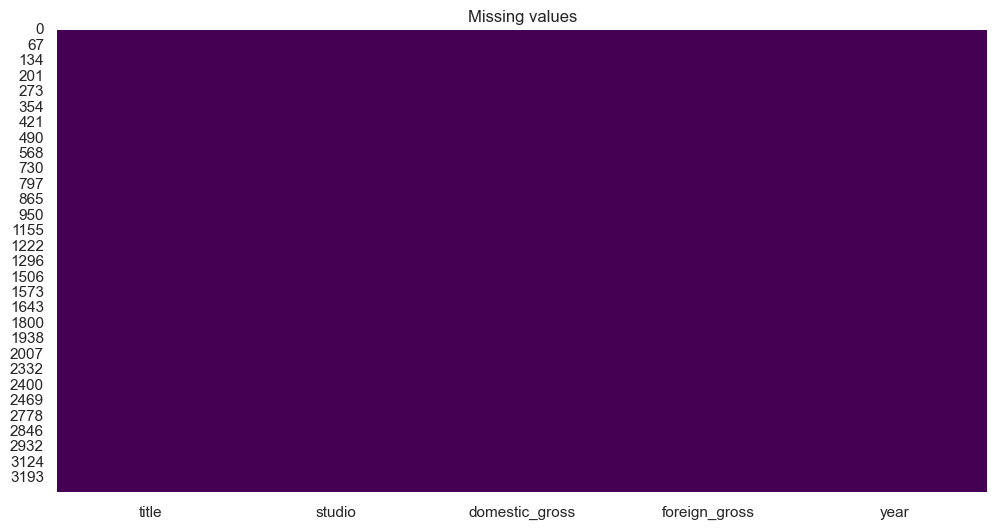

In [551]:
#using visualization to check if there any missing values using a heatmap
plt.figure(figsize=(12,6))
sns.heatmap(bom_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing values')
plt.show()

### 2.4 Loading Second Dataset

tn.movie_budgets.csv is the second dataset being used for our analysis.

In [552]:
tn_df = pd.read_csv(r"C:\Users\kabif\OneDrive\Desktop\Flatiron\phase 2.0\dsc-phase-2-project-v3\zippedData\tn.movie_budgets.csv\tn.movie_budgets.csv")
#Previewing first 10 rows
tn_df.head(10)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,"$306,000,000","$936,662,225","$2,053,311,220"
6,7,"Apr 27, 2018",Avengers: Infinity War,"$300,000,000","$678,815,482","$2,048,134,200"
7,8,"May 24, 2007",Pirates of the Caribbean: At Worldâs End,"$300,000,000","$309,420,425","$963,420,425"
8,9,"Nov 17, 2017",Justice League,"$300,000,000","$229,024,295","$655,945,209"
9,10,"Nov 6, 2015",Spectre,"$300,000,000","$200,074,175","$879,620,923"


In [553]:
#Previewing the last 10 rows
tn_df.tail(10)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
5772,73,"Jan 13, 2012",Newlyweds,"$9,000","$4,584","$4,584"
5773,74,"Feb 26, 1993",El Mariachi,"$7,000","$2,040,920","$2,041,928"
5774,75,"Oct 8, 2004",Primer,"$7,000","$424,760","$841,926"
5775,76,"May 26, 2006",Cavite,"$7,000","$70,071","$71,644"
5776,77,"Dec 31, 2004",The Mongol King,"$7,000",$900,$900
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0
5781,82,"Aug 5, 2005",My Date With Drew,"$1,100","$181,041","$181,041"


In [554]:
#checking the structure of the data
tn_df.shape
tn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [555]:
#check for missing values
tn_df.isnull().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [556]:
tn_df.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

### Data cleaning of Second dataset

In [557]:
#renaming the dataset
tn_df.columns = tn_df.columns.str.strip().str.lower().str.replace(" ", "_")
tn_df.columns

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross'],
      dtype='object')

### Cleaning Currency Column

Removing $ then changing to numeric and float.

Cleaning the production budget and domestic gross columns.

In [558]:
finances_columns = ['production_budget', 'domestic_gross', 'worldwide_gross']
for col in finances_columns:
    tn_df[col] = tn_df[col].replace('[\$,]', '', regex=True).astype(float)

In [559]:
#check the new data
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [560]:
#converting release_dsate to a easy date format
#bom_df['release_date'] = pd.to_datetime(bom_df['release_date'], errors='coerce')
tn_df['release_date'] = pd.to_datetime(tn_df['release_date'], errors='coerce')

In [561]:
tn_df.head(6)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09
5,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09


In [562]:
tn_df['release_date'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
5777    False
5778    False
5779    False
5780    False
5781    False
Name: release_date, Length: 5782, dtype: bool

In [563]:
tn_df = tn_df.dropna(subset=['release_date'])

Add the year column ti the release_date.

In [564]:
tn_df['year'] = tn_df['release_date'].dt.year
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,year
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2009
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,2011
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,2019
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,2015
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,2017


In [565]:
tn_df.info()
tn_df.describe()
tn_df.head()
tn_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross     5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
 6   year               5782 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(1)
memory usage: 293.7+ KB


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,year
5777,78,2018-12-31,Red 11,7000.0,0.0,0.0,2018
5778,79,1999-04-02,Following,6000.0,48482.0,240495.0,1999
5779,80,2005-07-13,Return to the Land of Wonders,5000.0,1338.0,1338.0,2005
5780,81,2015-09-29,A Plague So Pleasant,1400.0,0.0,0.0,2015
5781,82,2005-08-05,My Date With Drew,1100.0,181041.0,181041.0,2005


#### 2.5 Merging both Datasets

Before the merging of the two datsets we first examine the overlap between them and then clean and standardize the columns to ensure consistency.

In [566]:
#removing and spaces and lowercasing to ensure uniformity
bom_df['title'] = bom_df['title'].str.strip().str.lower()
tn_df['movie'] = tn_df['movie'].str.strip().str.lower()

In [567]:
common_titles =set(bom_df['title']).intersection(set(tn_df['movie']))
print("matching titles", len(common_titles))

matching titles 1107


### Merging Both Datasets

In [568]:
# Merging ON movie titles IS LEFT JOIN in order to retain budget information
merged_df = pd.merge(tn_df, bom_df, left_on='movie', right_on='title', how='left')

In [569]:
merged_df.head()

,id,release_date,movie,production_budget,domestic_gross_x,worldwide_gross,year_x,title,studio,domestic_gross_y,foreign_gross,year_y
0,1,2009-12-18,avatar,425000000.0,760507625.0,2.776345e+09,2009,NaN,NaN,NaN,NaN,NaN
1,2,2011-05-20,pirates of the caribbean: on stranger tides,410600000.0,241063875.0,1.045664e+09,2011,pirates of the caribbean: on stranger tides,BV,241100000.0,804600000.0,2011.0
2,3,2019-06-07,dark phoenix,350000000.0,42762350.0,1.497624e+08,2019,NaN,NaN,NaN,NaN,NaN
3,4,2015-05-01,avengers: age of ultron,330600000.0,459005868.0,1.403014e+09,2015,avengers: age of ultron,BV,459000000.0,946400000.0,2015.0
4,5,2017-12-15,star wars ep. viii: the last jedi,317000000.0,620181382.0,1.316722e+09,2017,NaN,NaN,NaN,NaN,NaN


In [570]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross_x   5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
 6   year_x             5782 non-null   int32         
 7   title              1114 non-null   object        
 8   studio             1113 non-null   object        
 9   domestic_gross_y   1114 non-null   float64       
 10  foreign_gross      1114 non-null   float64       
 11  year_y             1114 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int32(1), int64(1), object(3)
memory usage: 519.6+ KB


In [571]:
#dropping duplicates in the merged dataset
merged_df = merged_df.drop(columns=['title'])

In [572]:
#checking for any missing values
merged_df.isnull().sum()

id                      0
release_date            0
movie                   0
production_budget       0
domestic_gross_x        0
worldwide_gross         0
year_x                  0
studio               4669
domestic_gross_y     4668
foreign_gross        4668
year_y               4668
dtype: int64

In [573]:
#renaming columns to ensure uniforminty eg those with x 
merged_df = merged_df.rename(columns={'domestic_gross_x': 'domestic_gross', 'foreign_gross': 'foreign_gross_bom', 'studio': 'studio_bom'})
print(merged_df.columns)

Index(['id', 'release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross', 'year_x', 'studio_bom', 'domestic_gross_y',
       'foreign_gross_bom', 'year_y'],
      dtype='object')


In [574]:
#fill missing values with unknown
merged_df['studio_bom'] = merged_df['studio_bom'].fillna('unknown')

In [575]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross     5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
 6   year_x             5782 non-null   int32         
 7   studio_bom         5782 non-null   object        
 8   domestic_gross_y   1114 non-null   float64       
 9   foreign_gross_bom  1114 non-null   float64       
 10  year_y             1114 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int32(1), int64(1), object(2)
memory usage: 474.4+ KB


In [576]:
merged_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,year_x,studio_bom,domestic_gross_y,foreign_gross_bom,year_y
0,1,2009-12-18,avatar,425000000.0,760507625.0,2.776345e+09,2009,unknown,NaN,NaN,NaN
1,2,2011-05-20,pirates of the caribbean: on stranger tides,410600000.0,241063875.0,1.045664e+09,2011,BV,241100000.0,804600000.0,2011.0
2,3,2019-06-07,dark phoenix,350000000.0,42762350.0,1.497624e+08,2019,unknown,NaN,NaN,NaN
3,4,2015-05-01,avengers: age of ultron,330600000.0,459005868.0,1.403014e+09,2015,BV,459000000.0,946400000.0,2015.0
4,5,2017-12-15,star wars ep. viii: the last jedi,317000000.0,620181382.0,1.316722e+09,2017,unknown,NaN,NaN,NaN


In [601]:
#calculating worldwide gross
merged_df["worldwide_gross"] = merged_df["domestic_gross"] + merged_df["foreign_gross_bom"]

In [604]:
#calculating Profit and Return on investment
merged_df["profit"] = merged_df["worldwide_gross"] - merged_df["production_budget"]
merged_df["ROI"] = merged_df["profit"]/merged_df["production_budget"]

## 3.0 Enhancing the Dataset with IMDb information.

### Integrating the im.db Source

During the course of this analysis, i noticed that while the box office and budget datsets had offered financial insights , they also might have lacked details such as genre of movies , what ratings the audience gave and much more.These critical factors are influential to a film's perfomance and appeal.
Thereby in krder to strenghte the analysis done and provide more recommendation, i incorporated data from the im.db sqlite database. This dataset includes rich metadata in the style of IMDb such as classification of genre,user ratings and duration of films. These features will be instrumental in conduction of univariate bivariate and multu variate analysis.

#### Connecting to sql database amd loading the required tables.

In [605]:
conn = sqlite3.connect(r"C:\Users\kabif\OneDrive\Desktop\Flatiron\phase 2.0\dsc-phase-2-project-v3\zippedData\im.db\im.db")

In [606]:
#knowing the tables in the dataset
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""" ,conn)
print(tables)

            name
0   movie_basics
1      directors
2      known_for
3     movie_akas
4  movie_ratings
5        persons
6     principals
7        writers


In [607]:
#loading the required tables
movie_basics = pd.read_sql("""
SELECT *
FROM movie_basics
""", conn)
movie_ratings = pd.read_sql("""
SELECT *
FROM movie_ratings
""", conn)


In [608]:
#merging  the two tables to movie_id
im_df = pd.merge(movie_basics, movie_ratings, on="movie_id")

In [609]:
# checking for null values
im_df.isnull().sum()

movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
averagerating         0
numvotes              0
dtype: int64

In [610]:
#dropping null values.
im_df.dropna(subset=["runtime_minutes", "genres"], inplace=True)

In [611]:
#checking if there any null values
im_df.isnull().sum()

movie_id           0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
averagerating      0
numvotes           0
dtype: int64

In [612]:
#conversion of data types
im_df["start_year"] = im_df["start_year"].astype(int)
im_df["runtime_minutes"] = im_df["runtime_minutes"].astype(int)

In [613]:
#dropping first genre in order to simplify
im_df["main_genres"] = im_df["genres"].apply(lambda x: x.split(",")[0] if "," in x else x)

In [614]:
#check the cleaned data
im_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,main_genres
0,tt0063540,Sunghursh,Sunghursh,2013,175,"Action,Crime,Drama",7.0,77,Action
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114,"Biography,Drama",7.2,43,Biography
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122,Drama,6.9,4517,Drama
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80,"Comedy,Drama,Fantasy",6.5,119,Comedy
6,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83,"Adventure,Animation,Comedy",8.1,263,Adventure


In [615]:
im_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,main_genres
73849,tt9911774,Padmavyuhathile Abhimanyu,Padmavyuhathile Abhimanyu,2019,130,Drama,8.4,365,Drama
73850,tt9913056,Swarm Season,Swarm Season,2019,86,Documentary,6.2,5,Documentary
73851,tt9913084,Diabolik sono io,Diabolik sono io,2019,75,Documentary,6.2,6,Documentary
73852,tt9914286,Sokagin Çocuklari,Sokagin Çocuklari,2019,98,"Drama,Family",8.7,136,Drama
73855,tt9916160,Drømmeland,Drømmeland,2019,72,Documentary,6.5,11,Documentary


In [616]:
#final cleaning for merging
merged_df["movie_clean"] = merged_df["movie"].str.strip().str.lower()
im_df["clean_title"] = im_df["primary_title"].str.strip().str.lower()

In [617]:
#merge the cleaned dataset
final_df = pd.merge(merged_df,im_df, left_on="movie_clean", right_on="clean_title", how="inner")

In [619]:
final_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,year_x,studio_bom,domestic_gross_y,foreign_gross_bom,...,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,main_genres,clean_title
0,1,2009-12-18,avatar,425000000.0,760507625.0,NaN,2009,unknown,NaN,NaN,...,tt1775309,Avatar,Abatâ,2011,93,Horror,6.1,43,Horror,avatar
1,2,2011-05-20,pirates of the caribbean: on stranger tides,410600000.0,241063875.0,1.045664e+09,2011,BV,241100000.0,804600000.0,...,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136,"Action,Adventure,Fantasy",6.6,447624,Action,pirates of the caribbean: on stranger tides
2,3,2019-06-07,dark phoenix,350000000.0,42762350.0,NaN,2019,unknown,NaN,NaN,...,tt6565702,Dark Phoenix,Dark Phoenix,2019,113,"Action,Adventure,Sci-Fi",6.0,24451,Action,dark phoenix
3,4,2015-05-01,avengers: age of ultron,330600000.0,459005868.0,1.405406e+09,2015,BV,459000000.0,946400000.0,...,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141,"Action,Adventure,Sci-Fi",7.3,665594,Action,avengers: age of ultron
4,7,2018-04-27,avengers: infinity war,300000000.0,678815482.0,NaN,2018,unknown,NaN,NaN,...,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149,"Action,Adventure,Sci-Fi",8.5,670926,Action,avengers: infinity war


In [620]:
print(im_df["runtime_minutes"].head())
print(im_df["runtime_minutes"].dtype)
print(im_df["runtime_minutes"].isna().sum())

0    175
1    114
2    122
4     80
6     83
Name: runtime_minutes, dtype: int32
int32
0


### Summary of the Data Preparation

  1.Merged bom_df and tn_df into a merged_df
  
 2.Load sql tables into im.db
 
 3.leaned all the datasets and then joined them to one final dataframe final_df

### EDA[Explatory Data Analysis]


### Univariate analysis

#### 1. Distribution Ratings

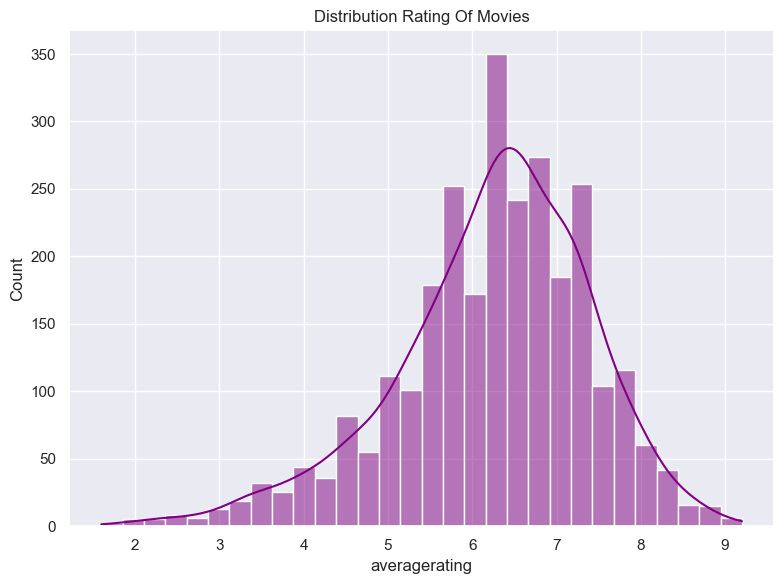

In [621]:
plt.figure(figsize=(8,6))
sns.histplot(final_df["averagerating"], bins=30, kde=True, color="purple")
plt.title("Distribution Rating Of Movies")
plt.tight_layout()
plt.show()

#### 2 Count of Movies by Main Genre

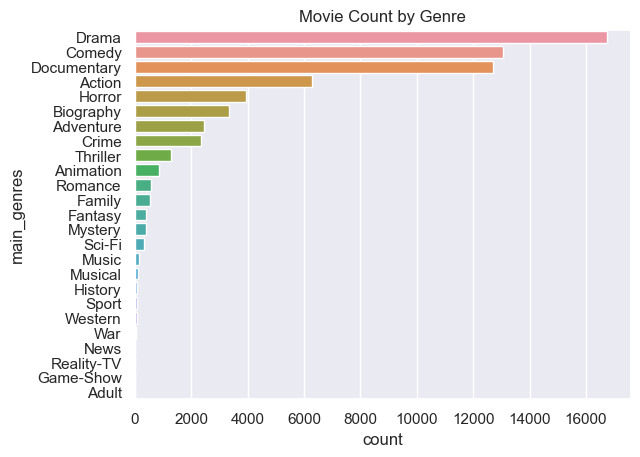

In [622]:
sns.countplot(y="main_genres", data=im_df,order=im_df["main_genres"].value_counts().index)
plt.title("Movie Count by Genre")
plt.show()

### 3 Distribution of Ratings

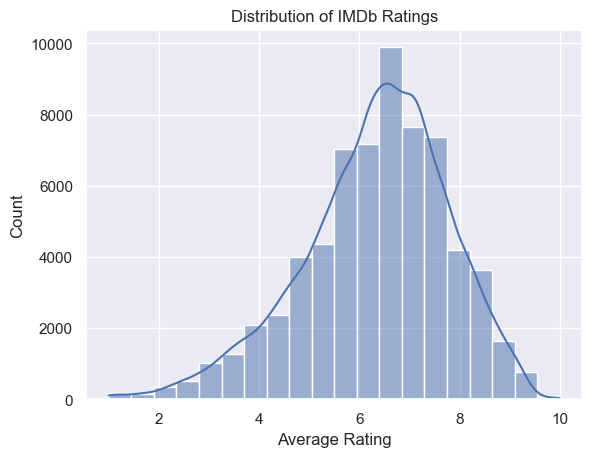

In [623]:
sns.histplot(im_df["averagerating"].dropna(), bins=20, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("Average Rating")
plt.show()

### 4vDistribution of Domestic Gross

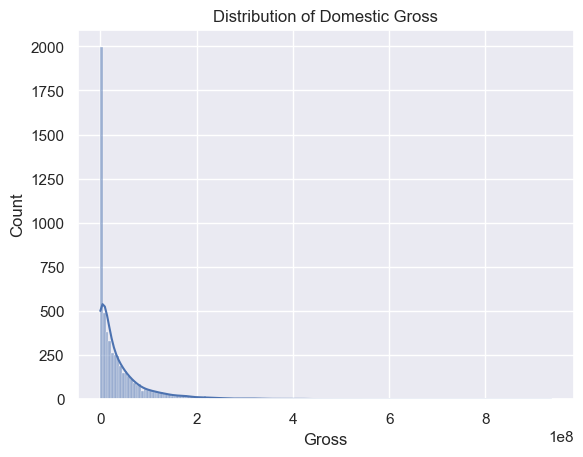

In [624]:
sns.histplot(merged_df["domestic_gross"].dropna(), kde=True)
plt.title("Distribution of Domestic Gross")
plt.xlabel("Gross")
plt.show()

### Top 10 Studios by Movie Count

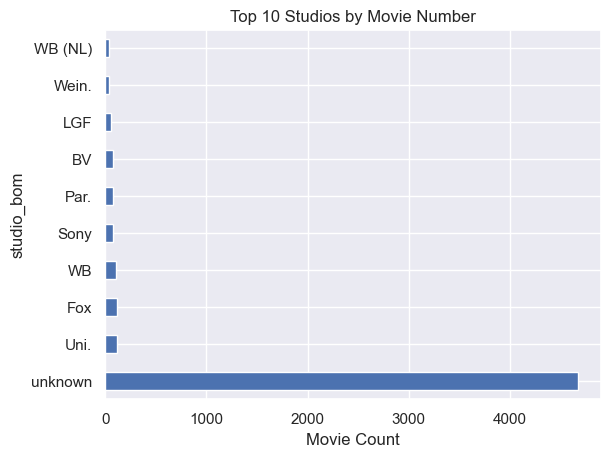

In [625]:
merged_df["studio_bom"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Studios by Movie Number")
plt.xlabel("Movie Count")
plt.show()

## 2 Bivariate Analysis(two variables)
We will be exploring the relationship of two variables.

### 1. Average Rating and Runtime

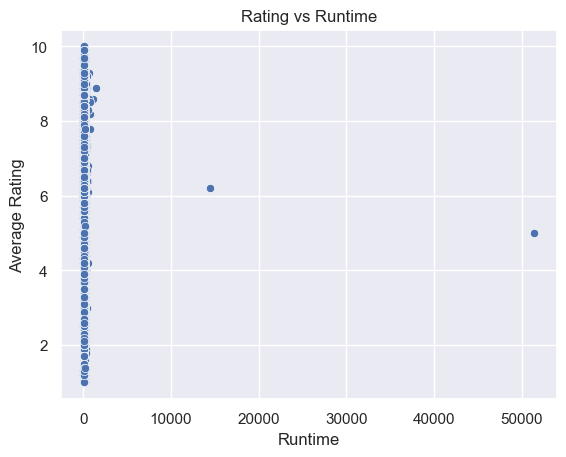

In [626]:
sns.scatterplot(x="runtime_minutes", y="averagerating", data=im_df)
plt.title("Rating vs Runtime")
plt.xlabel("Runtime")
plt.ylabel("Average Rating")
plt.show()

### Rating by Genre 

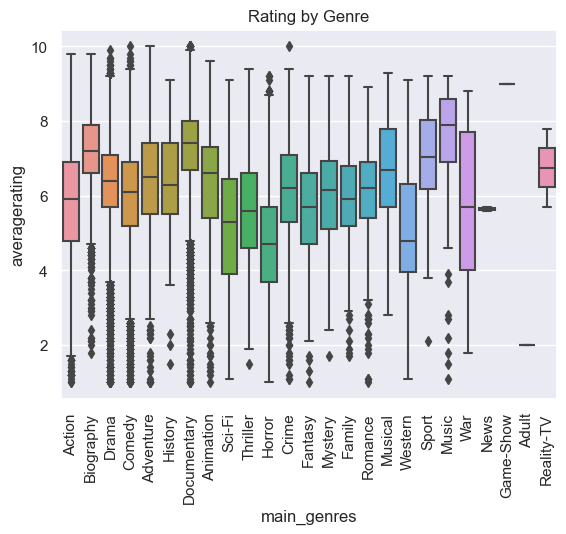

In [627]:
sns.boxplot(x="main_genres", y="averagerating", data=im_df)
plt.xticks(rotation=90)
plt.title("Rating by Genre")
plt.show()

### Domestic Gross and Foreign Gross

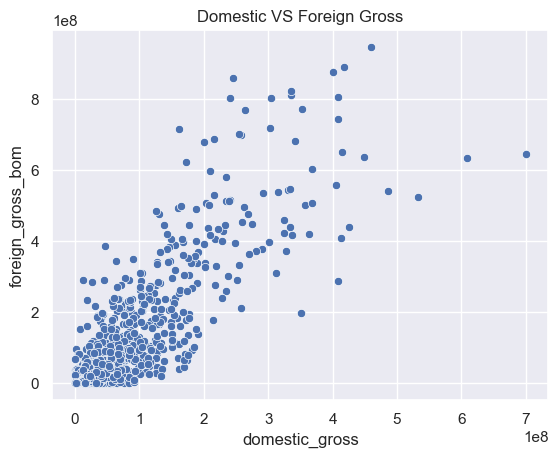

In [628]:
sns.scatterplot(x="domestic_gross", y="foreign_gross_bom", data=merged_df)
plt.title("Domestic VS Foreign Gross")
plt.show()

### Budget vs Domestic Gross

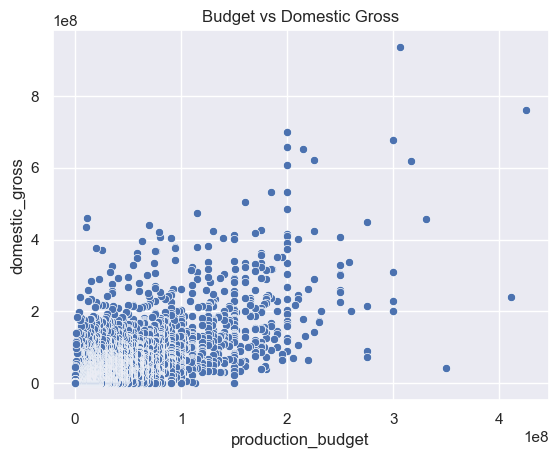

In [629]:
sns.scatterplot(x="production_budget", y="domestic_gross" ,data=merged_df)
plt.title("Budget vs Domestic Gross")
plt.show()

### Average Studio rating for Top 10 studios only

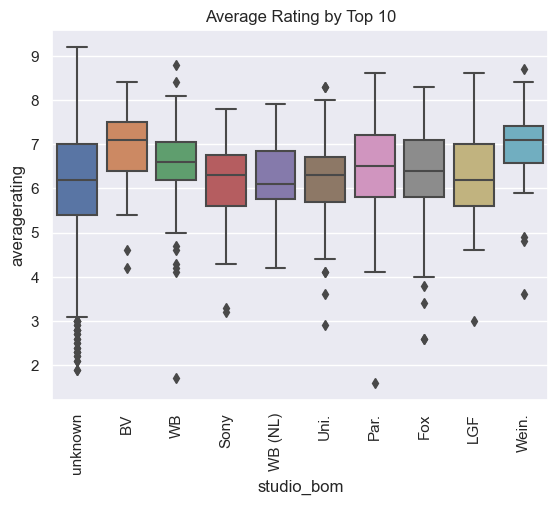

In [630]:
top_studios = merged_df["studio_bom"].value_counts().head(10).index
sns.boxplot(x="studio_bom", y="averagerating", data=final_df[final_df["studio_bom"].isin(top_studios)])
plt.xticks(rotation=90)
plt.title("Average Rating by Top 10")
plt.show()

## Multivariate Analysis[ more than 3 variables]

### Scatterplot: Budget vs Domestic Gross with colour rating

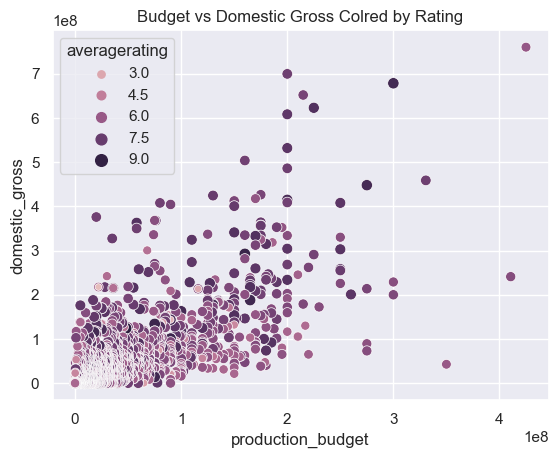

In [631]:
sns.scatterplot(x="production_budget", y="domestic_gross", hue="averagerating", size="averagerating", data=final_df)
plt.title("Budget vs Domestic Gross Colred by Rating")
plt.show()

### Correlation Heatmap

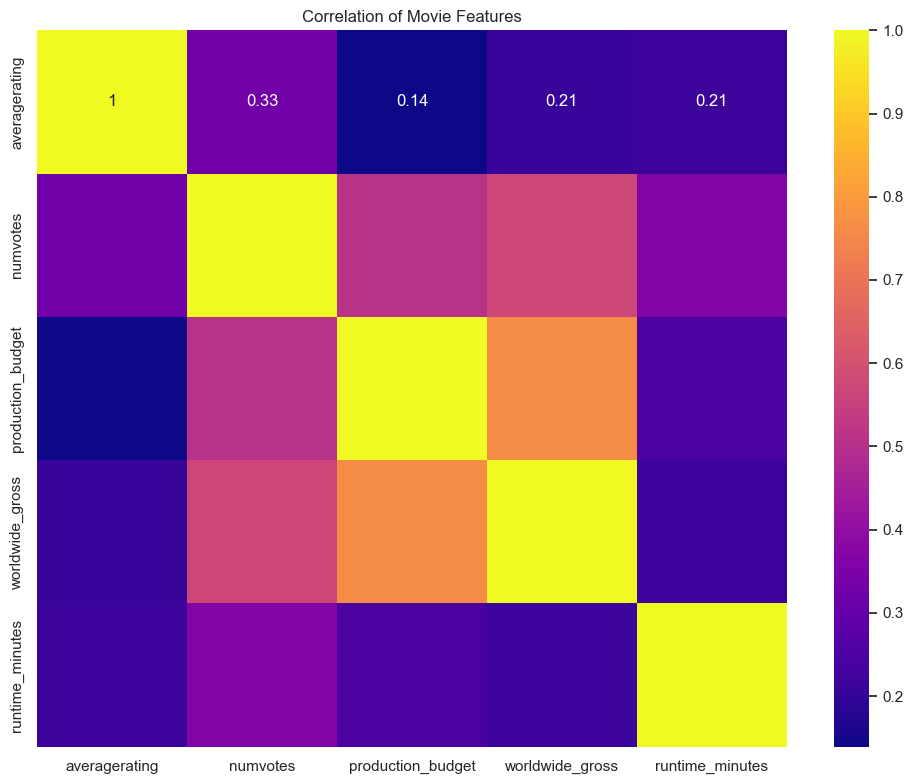

In [632]:
numerical_cols = final_df[["averagerating", "numvotes", "production_budget", "worldwide_gross" , "runtime_minutes"]]
plt.figure(figsize=(10,8))
sns.heatmap(numerical_cols.corr(), annot=True, cmap="plasma")
plt.title("Correlation of Movie Features")
plt.tight_layout()
plt.show()

# 5 Evaluation of Data

#### In this phase i evaluate the value of the insight gathered throughout the analysis.The goal is to determine whether the data helps in informing decisions that are strategic and align with studios objectives
#### Summary includes:
 ##### ~Identification of genres that are constantly performing well in the film industry
 ##### ~Analyzing how different elements might affect a films success and they icludee the budget, audience ratings and movie genre
 ##### ~Translation of analytical findings for future movie production recommendations and decision making

### EXPORTING 


In [633]:
#Export final Data to csv.
final_df.to_csv("final_analysis.csv", index=False)